# Análisis de Plataforma de Comida por Envío "Instacart"
---
Descripción:

En este proyecto, se trabaja con un conjunto de datos modificado de Instacart, una plataforma de entregas de comestibles similar a Uber Eats o Door Dash. El conjunto de datos original fue reducido en tamaño para agilizar los cálculos y se introdujeron valores ausentes y duplicados, conservando cuidadosamente las distribuciones originales. El objetivo es completar tres pasos de análisis, documentando cada uno con una introducción clara sobre la estrategia a seguir, párrafos explicatorios que justifiquen las decisiones tomadas y una conclusión final que resuma los hallazgos y las elecciones realizadas.

El primer paso consistirá en la limpieza y preparación de los datos. Se identificarán y tratarán los valores ausentes, ya sea mediante eliminación o imputación según el contexto y la relevancia de cada variable. Asimismo, se localizarán y eliminarán los registros duplicados. Las decisiones se justificarán con base en el impacto potencial sobre la integridad del análisis y en el mantenimiento de las distribuciones originales.

El segundo paso se centrará en el análisis exploratorio de los datos. Se examinarán las distribuciones de variables clave como productos, horarios de pedidos y frecuencia de compra. Se emplearán visualizaciones para detectar patrones o anomalías. Cada elección metodológica—como el tipo de gráfico o la agregación de datos—se explicará en función de los objetivos del análisis.

El tercer paso abordará la extracción de conclusiones orientadas a la operación de la plataforma. Se buscarán relaciones entre variables que puedan informar decisiones de negocio, como la identificación de productos más recurrentes o franjas horarias de mayor demanda. Las decisiones estadísticas y de interpretación se justificarán de manera explícita.

Finalmente, se presentará una conclusión que resuma los hallazgos más relevantes, las decisiones técnicas adoptadas en cada paso y cómo estas afectan la validez de los resultados obtenidos.

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# 1. Preprocesamiento de los Datos

In [ ]:
# Primero, procedo a importar mis librerias de pandas y pyplot para trabajar con DataFrame 
# diferentes tipos de visualización de los datos.
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
# En segundo lugar, paso a cargar los cinco documentos CSV dentro de mi workspace, usando para ello 
# el método 'read_csv', con los parámetros sep=';' y header=0, para asegurarme de que se ordenen bien 
# los datos en cada columna y que toma la primera fila con valor 0 como el encabezado de la tabla.

df_ic = pd.read_csv('/datasets/instacart_orders.csv', sep=';', header=0) # Variable que almacena el DataFrame "instacart_orders"
df_pds = pd.read_csv('/datasets/products.csv', sep=';', header=0) # Variable que almacena el DataFrame "products"
df_opds = pd.read_csv('/datasets/order_products.csv', sep=';', header=0) # Variable que almacena el DataFrame "order_products"
df_as = pd.read_csv('/datasets/aisles.csv', sep=';', header=0) # Variable que almacena el DataFrame "aisles"
df_dpts = pd.read_csv('/datasets/departments.csv', sep=';', header=0) # Variable que almacena el DataFrame "departments"


In [ ]:
# Muestro la información del DataFrame
print(df_ic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [ ]:
# Muestro la información del DataFrame
print(df_pds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [ ]:
# Muestro la información del DataFrame
print(df_opds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


In [ ]:
# Muestro la información del DataFrame
print(df_as.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [ ]:
# Muestro la información del DataFrame
print(df_dpts.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


### Comentarios

Cada uno de los DataFrames poseen un número de observaciones diferente, además de que en prácticamente todos hay valores ausentes en alguna de sus columnas o variables. A primera vista, no es posible descifrar si hay valores duplicados, pero eso se explorará en la siguiente sección. Finalmente, cabe destacar que algunas columnas precisan de ser transformadas a otro tipo de dato. En particular, 'add_to_cart_order' y 'days_since_prior_order' precisan de ser cambiadas de tipo 'float' a 'integer'. 

## Valores Duplicados
A continuación procedemos con la examinación de los valores duplicados en todos los dataframe y su correspondiente eliminación. Para mayor orden, pondremos un subtitulo indicando qué dataframe se está trabajando en cada parte respectivamente.

### `orders` data frame

In [ ]:
# Reviso si hay pedidos duplicados en el dataframe "df_ic"
print(df_ic.duplicated().sum())

15


El DataFrame 'df_ic' tiene filas duplicadas, 15 en específico. 

In [ ]:
# Basándome en los hallazgos, verifico todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
pedidos_miercoles_2am = df_ic[(df_ic['order_dow'] == 3) & (df_ic['order_hour_of_day'] == 2)]
pedidos_miercoles_2am

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


El DataFrame sugiere que existen 121 pedidos que se realizaron el miércoles a las 2 am. 

In [ ]:
# Elimino los pedidos duplicados
df_ic = df_ic.drop_duplicates().reset_index(drop=True)

In [ ]:
# Vuelvo a verificar si hay filas duplicadas
print(df_ic.duplicated().sum())
df_ic.head()

0


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [ ]:
# Vuelvo a verificar únicamente si hay IDs duplicados de pedidos
df_ic['order_id'].duplicated().sum()

0

La eliminación de valores duplicados evitará múltiples problemas al momento de realizar el análisis y, por supuesto, la visualización de los datos. 

### `products` data frame

In [ ]:
# Verifico si hay filas totalmente duplicadas
df_pds.duplicated().sum()

0

In [ ]:
# Reviso únicamente si hay ID de productos duplicados
df_pds['product_id'].duplicated().sum()

0

In [ ]:
# Reviso únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

df_pds['product_name'] = df_pds['product_name'].str.upper()
df_pds['product_name']
print(df_pds['product_name'].duplicated().sum())

1361


In [ ]:
# Reviso si hay nombres duplicados de productos no faltantes
# Filtro solo los nombres que no son nulos
nombres_no_nulos = df_pds['product_name'].dropna()

# Cuento duplicados en los nombres no faltantes
duplicados_no_faltantes = nombres_no_nulos.duplicated().sum()
print(f"Nombres duplicados (excluyendo valores ausentes): {duplicados_no_faltantes}")

Nombres duplicados (excluyendo valores ausentes): 104


En esta parte me encontré con 1361 valores duplicados en la variable 'product_name' del DataFrame 'df_pds'. Aquí es importante hacer notar que, como los valores que adquiere esta columna son de tipo string o cadenas de texto, una técnica acertada que puede ayudar en estos casos para encontrar duplicados es convertirlos todos a minusculas o mayúsculas, ya que esto permite darle un formato homogéneo a todos los datos. De esta manera, el método duplicated los puede detectar más fácilmente o sin riesgo dejar valores idénticos pero escritos de diferente modo. Posteriormente, se realiza una ulterior filtración, en donde se eliminan aquellos datos NaN o ausentes, para volver a verificar si existen duplicados. Con ello, se asegura que los datos estén enteramente limpios. Eso fue lo que realicé en esta sección. 

### `departments` data frame

In [17]:
# Reviso si hay filas totalmente duplicadas
df_dpts.duplicated().sum()

0

In [18]:
# Reviso únicamente si hay IDs duplicadas de departamentos
df_dpts['department_id'].duplicated().sum()

0

No hay datos duplicados para el DataFrame 'df_dpts'.

### `aisles` data frame

In [19]:
# Reviso si hay filas totalmente duplicadas
df_as.duplicated().sum()

0

In [20]:
# Reviso únicamente si hay IDs duplicadas de pasillos
df_as['aisle_id'].duplicated().sum()

0

No hay datos duplicados para el DataFrame 'df_as'.

### `order_products` data frame

In [21]:
# Reviso si hay filas totalmente duplicadas
df_opds.duplicated().sum()

0

No hay datos duplicados para el DataFrame 'df_opds'. 

## Valores Ausentes
Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes en las siguientes columnas y tablas:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [ ]:
# Busco los valores ausentes en la columna 'product_name'
df_pds['product_name'].isna().sum()

1258

Hay un sólo valor ausente en la columna 'product_name' del DataFrame 'df_pds'.

In [ ]:
#  En el ejercicio, se pregunta: ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
# Para responderla, primero es preciso guardar aquellas filas con valores ausentes en la columna 
# 'product_name' dentro de una nueva variable, para poder trabajar más facilmente con ella.
productos_nan = df_pds[df_pds['product_name'].isna()]
print(productos_nan.head(40))

# Ver qué pasillos tienen estos productos faltantes
print("Pasillos de productos sin nombre:")
print(productos_nan['aisle_id'].unique())
# El pasillo cien es en el que se ubica dicho valor ausente sin nombre.

# Verificar si todos están en el pasillo 100.
pdts_nan_pa100 = (productos_nan['aisle_id'] == 100).all()
print(pdts_nan_pa100)

      product_id product_name  aisle_id  department_id
37            38          NaN       100             21
71            72          NaN       100             21
109          110          NaN       100             21
296          297          NaN       100             21
416          417          NaN       100             21
436          437          NaN       100             21
439          440          NaN       100             21
471          472          NaN       100             21
490          491          NaN       100             21
555          556          NaN       100             21
561          562          NaN       100             21
613          614          NaN       100             21
623          624          NaN       100             21
689          690          NaN       100             21
767          768          NaN       100             21
803          804          NaN       100             21
890          891          NaN       100             21
990       

Aquí las técnicas de filtrado lógico me permitieron aislar el pasillo donde se encuentra el valor ausente. Una vez detectado en qué pasillo se encuentra, sólo queda averiguar el departamento para que, de esa manera, sea más fácil descubrir cuál es el producto en cuestión cuyo no nombre falta en la base de datos. 

In [ ]:
# En el ejercicio, se pregunta: ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
# Para responder, tengo que apreciar antes que nada qué departamentos tienen productos ausentes.

print("departamentos con productos sin nombre:")
print(productos_nan['department_id'].unique())

# Verifico si todos están en el departamento con ID 21
pdts_nan_dpt21 = (productos_nan['department_id'] == 21).all()
pdts_nan_dpt21

departamentos con productos sin nombre:
[21]


True

Se hizo básicamente lo mismo que en el ejercicio del pasillo, filtrando primero y luego con el método .unique() encontrar en qué departamento se halla dicho valor ausente. 

In [ ]:
# En el ejercicio, se solicita que use las tablas "department" y "aisle" para revisar los datos del pasillo con ID 100 y el departamento con ID 21.

# Ver qué pasillo es el ID 100
aisle_100 = df_as[df_as['aisle_id'] == 100]
print(aisle_100)

# Ver qué departamento es el ID 21  
department_21 = df_dpts[df_dpts['department_id'] == 21]
print(department_21)

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


En ambos IDs, falta el nombre, tanto del pasillo como del departamento. Esto podría entorpecer un poco las cosas si queremos también ubicar el nombre del producto faltante anteriormente. Pero las coordenadas fundamentales ya las tenemos: pasillo 100, departamento 21. 

In [ ]:
# Completo los nombres de productos ausentes con 'Unknown'
df_pds['product_name'].fillna('Unknown', inplace=True)
print(f"Compleción de los valores ausentes con 'Unknown': \n {df_pds[df_pds['product_name'] == 'Unknown']}")
print(f"Numéro de valores ausentes (verificación): {df_pds['product_name'].isna().sum()}")

Compleción de los valores ausentes con 'Unknown': 
        product_id product_name  aisle_id  department_id
37             38      Unknown       100             21
71             72      Unknown       100             21
109           110      Unknown       100             21
296           297      Unknown       100             21
416           417      Unknown       100             21
...           ...          ...       ...            ...
49552       49553      Unknown       100             21
49574       49575      Unknown       100             21
49640       49641      Unknown       100             21
49663       49664      Unknown       100             21
49668       49669      Unknown       100             21

[1258 rows x 4 columns]
Numéro de valores ausentes (verificación): 0


Nos deshacemos del valor ausente al sustituirlo por el texto 'Unknown'. Esto es mejor que dejarlo en NaN, por supuesto, ya que puede ayudarnos a prevenir cualquier eventualidad en el análisis. 

### `orders` data frame

In [27]:
# Encuentra los valores ausentes
df_ic.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [ ]:
# En el ejercicio, se pregunta: ¿Hay algún valor ausente que no sea el primer pedido del cliente?
# Para responder, tengo que seguir los siguientes pasos:

# Paso 1: Filtrar las FILAS que tienen NaN (no solo contarlas)
orders_nan = df_ic[df_ic['days_since_prior_order'].isna()]

# Paso 2: Ver cuántos registros tienen
print(f"Total de pedidos con NaN: {len(orders_nan)}")

# Paso 3: De esos pedidos con NaN, filtrar los que NO son primer pedido
orders_nan_npp = orders_nan[orders_nan['order_number'] != 1]

# Paso 4: Ver el resultado
print(f"Pedidos con NaN que NO son primer pedido: {len(orders_nan_npp)}")

Total de pedidos con NaN: 28817
Pedidos con NaN que NO son primer pedido: 0


A diferencia del ejercicio anterior con el DataFrame 'df_pds', aquí los valores NaN no se deben a un probable fallo en la recopilación de los datos, sino que tienen un sentido dentro de la propia estructura del DataFrame. En primer lugar, es necesario ubicar dónde están los valores ausentes (en este caso, en la variable 'days_since_prior_order', la cual refiere al número de días transcurridos desde que este cliente hizo su pedido anterior).En segundo lugar, se pide que se corrobore si existe algún valor ausente que no sea el primer pedido del cliente. Esto es así ya que, naturalmente, el primer pedido no posee un número de días transcurridos desde que se realizó el anterior, ya que representa precisamente el primer pedido. Por consiguiente, todos los valores '1' en la variable 'order_number' se corresponden con un NaN en la variable 'days_since_prior_order'. 

Posteriormente, se creó una variable donde, mediante un filtrado, se almacenen aquellas filas con valores ausentes que no se correspondan con el primer pedido. El resultado arrojado fue cero. 

No se eliminaron dichos valores ausentes porque, de manera evidente, son datos imprescindibles, en la medida en que se corresponden con el primer pedido de los clientes. Y tampoco se llenaron con la mediana, ya que rompería con el sentido del DataFrame, pues cae en el absurdo de que al primer pedido le corresponda un número de días transcurridos desde que este cliente hizo su pedido anterior. Todo esto es muestra de la importancia de entender nuestra base de datos. 

### `order_products` data frame

In [ ]:
# Encuentro los valores ausentes
df_opds.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [ ]:
# Calculo los valores mínimos y máximos de la columna 'add_to_cart_order'.
print(df_opds['add_to_cart_order'].min())
print(df_opds['add_to_cart_order'].max())

1.0
64.0


el rango de valores de la variable 'add_to_cart_order' (que refiere al orden secuencial en el que se añadió cada artículo en el carrito) va del 1 al 64. Por otra parte, cuenta con 836 valores ausentes.  

In [ ]:
# Guardo todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
print(df_opds['add_to_cart_order'].isna().sum())
vps_atco = df_opds['add_to_cart_order'].isna()
print(f"Verificación de que se hayan guardado todos los valores ausentes en la variable 'vps_atco': \n {vps_atco[vps_atco == True]}")
filas_con_nan = df_opds[vps_atco]
ids_vps_atco = filas_con_nan['order_id']
print(ids_vps_atco.unique())


836
Verificación de que se hayan guardado todos los valores ausentes en la variable 'vps_atco': 
 737        True
9926       True
14394      True
16418      True
30114      True
           ... 
4505662    True
4511400    True
4517562    True
4534112    True
4535739    True
Name: add_to_cart_order, Length: 836, dtype: bool
[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [ ]:
# En el ejercicio, se pregunta: ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Para responder, primero tengo que realizar los siguientes pasos:

# Paso 1: Obtener los order_ids que tienen valores faltantes
pedidos_con_faltantes = df_opds[df_opds['add_to_cart_order'].isna()]['order_id'].unique()

# Paso 2: Para cada uno de esos pedidos, contar el TOTAL de productos
total_productos_por_pedido = df_opds[df_opds['order_id'].isin(pedidos_con_faltantes)].groupby('order_id').size()

# Paso 3: Verificar cuántos tienen más de 64 productos
pedidos_mas_64 = (total_productos_por_pedido > 64).sum()
print(f"Pedidos con faltantes que tienen más de 64 productos: {pedidos_mas_64}")
print(f"Total de pedidos con faltantes: {len(pedidos_con_faltantes)}")


Pedidos con faltantes que tienen más de 64 productos: 70
Total de pedidos con faltantes: 70


Hay un total de pedidos 70 con valores ausentes la variable 'add_to_cart_order' que tienen más de 64 productos. Por otra parte, el total de pedidos con valores ausentes también es de 70. De esta forma, se infiere que todos los pedidos con valores ausentes tienen más de 64 productos. 

In [ ]:
# Remplazo los valores ausentes en la columna 'add_to_cart? con 999 y convierto la columna al tipo entero.

df_opds.fillna({'add_to_cart_order': 999}, inplace=True)
df_opds['add_to_cart_order'] = df_opds['add_to_cart_order'].astype('int')
df_opds[df_opds['add_to_cart_order'] == 999]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,999,0
9926,1968313,43867,999,0
14394,2926893,11688,999,0
16418,1717990,4142,999,0
30114,1959075,42828,999,1
...,...,...,...,...
4505662,1800005,7411,999,0
4511400,1633337,260,999,0
4517562,404157,9517,999,0
4534112,1673227,17835,999,0


Se remplazó con '999' cada valor ausente y luego se transformaron a tipo 'integer'. 

## Comentarios

El proceso de preprocesamiento realizado resulta metodológicamente sólido y consistente con las características específicas del conjunto de datos. En particular, destaca una adecuada distinción entre valores ausentes que representan errores o vacíos de información (como en 'product_name') y aquellos que tienen un significado estructural dentro del dataset (como 'days_since_prior_order' en primeros pedidos). Esta diferenciación es clave, ya que evita introducir sesgos artificiales mediante imputaciones inapropiadas.

Asimismo, la estrategia para tratar duplicados en 'product_name' mediante la normalización de texto (uso de minúsculas) es una decisión técnicamente acertada, pues reconoce la naturaleza semántica de los datos categóricos. Esto muestra una comprensión más profunda del problema más allá de una simple aplicación mecánica de métodos.

Por otro lado, la decisión de reemplazar valores ausentes en 'add_to_cart_order' por un valor extremo (999) es funcional desde una perspectiva operativa (evitar errores de tipo), pero introduce una codificación artificial que podría afectar análisis posteriores si no se maneja con cuidado. Este tipo de decisiones deben documentarse claramente—como se ha hecho—y considerarse en fases analíticas posteriores.

En términos generales, el preprocesamiento refleja un buen equilibrio entre limpieza de datos y preservación de la lógica interna del dataset, lo cual fortalece la validez de los análisis exploratorios posteriores.

# 3. Análisis de los datos
## Parte I
Para esta parte, las instrucciones son las siguientes:

[a] Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).

[b] Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.

[c] Crea un gráfico que muestre qué día de la semana la gente hace sus compras.

[d] Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [a] Verifica que los valores sean sensibles

In [ ]:
print(df_ic['order_dow'].describe())
print(df_ic['order_hour_of_day'].describe())

count    478952.000000
mean          2.775051
std           2.045901
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: order_dow, dtype: float64
count    478952.000000
mean         13.447034
std           4.224567
min           0.000000
25%          10.000000
50%          13.000000
75%          16.000000
max          23.000000
Name: order_hour_of_day, dtype: float64


In [35]:
print(sorted(df_ic['order_dow'].unique()))
print(sorted(df_ic['order_hour_of_day'].unique()))

[0, 1, 2, 3, 4, 5, 6]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


Los valores coinciden y son coherentes con lo que representan sus variables respectivas. Los días de la semana van de 0 a 6 (es decir, de domingo a sábado), mientras que las horas del día son 24, yendo de 0 a 23. 

### [b] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [36]:
personas_hd = df_ic.groupby('order_hour_of_day')['order_id'].count()
print(f"la cantidad de personas que hacen pedidos por hora del día es de: \n {personas_hd}")

la cantidad de personas que hacen pedidos por hora del día es de: 
 order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_id, dtype: int64


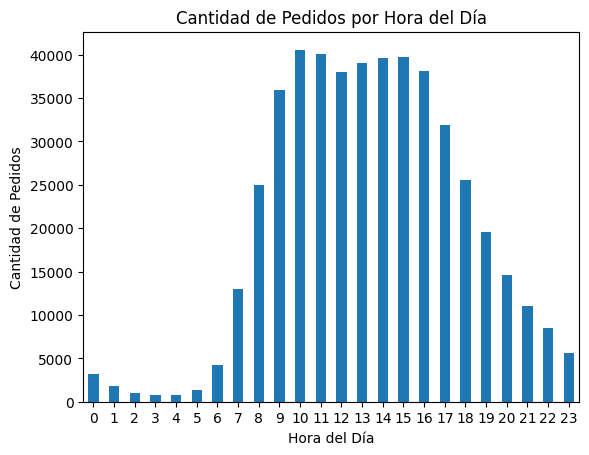

In [37]:
from matplotlib import pyplot as plt
import seaborn as sns 

personas_hd.plot(kind='bar', 
                 title='Cantidad de Pedidos por Hora del Día', 
                 xlabel='Hora del Día', 
                 ylabel='Cantidad de Pedidos',
                 rot=360)
plt.show()

La tabla se asemeja a una distribución normal con los datos bastante concentrados en torno a las horas 11 y 12 (entre los cuales se halla la mediana). No obstante, el pico de pedidos se realiza entre las 10 y 11 am. 

### [c] ¿Qué día de la semana compran víveres las personas?

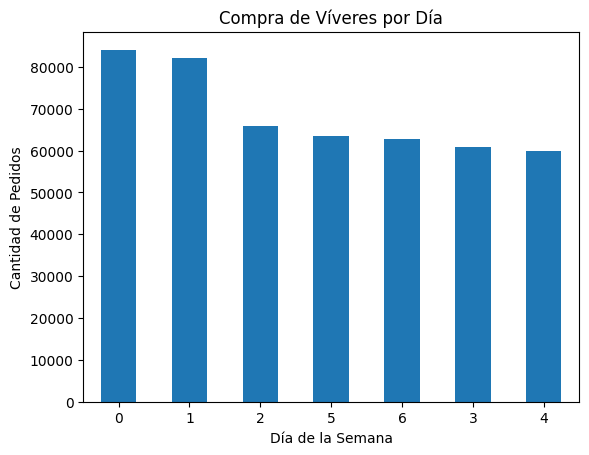

In [38]:
dow_compras = df_ic['order_dow'].value_counts()
dow_compras.plot(kind='bar', 
                 title='Compra de Víveres por Día', 
                 xlabel='Día de la Semana', 
                 ylabel='Cantidad de Pedidos',
                 rot=360)
plt.show()

Las personas suelen comprar sus víveres los domingos y lunes, disminuyendo gradualmente conforme pasa la semana. 

### [d] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [39]:
pedidos_te = df_ic.groupby('days_since_prior_order')['order_id'].count()
pedidos_te = pedidos_te.reset_index()
print(pedidos_te['days_since_prior_order'].min())
print(pedidos_te['days_since_prior_order'].max())

0.0
30.0


<AxesSubplot:title={'center':'Tiempo de Espera en Días por Pedido'}, xlabel='Cantidad de Días que las Personas Esperan', ylabel='Cantidad de Pedidos'>

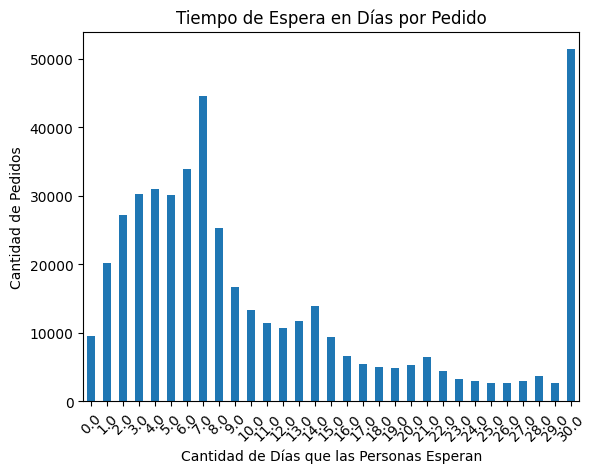

In [40]:
pedidos_te.plot(x='days_since_prior_order',
                 kind='bar', 
                 title='Tiempo de Espera en Días por Pedido', 
                 xlabel='Cantidad de Días que las Personas Esperan', 
                 ylabel='Cantidad de Pedidos',
                 rot=45,
                 legend=False)

La mayor cantidad de pedidos, poco más de 50,000, se realizaron a los 30 días de espera por parte de las personas; después, con aproximadamente 45,000 pedidos, le siguen los 7 días de espera. Después la mayor concentración se encuentra entre el día 1 y 6 respectivamente. 

## Parte II 
Para esta parte, las instrucciones son las siguientes:

[a] ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.

[b] Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).

[c] ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [a] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [41]:
saba_y_mier = df_ic[df_ic['order_dow'].isin([3, 6])]
dif_dias = saba_y_mier.groupby(['order_hour_of_day', 'order_dow'])['order_id'].count().unstack(fill_value=0)
dif_dias


order_dow,3,6
order_hour_of_day,,
0,373,464
1,215,254
2,106,177
3,101,125
4,108,118
5,170,161
6,643,451
7,1732,1619
8,3125,3246


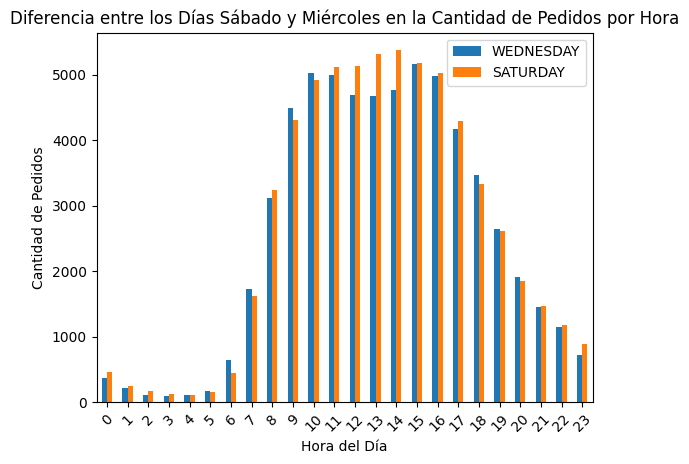

In [42]:
dif_dias.plot(kind='bar', xlabel='Hora del Día', ylabel='Cantidad de Pedidos', title='Diferencia entre los Días Sábado y Miércoles en la Cantidad de Pedidos por Hora', rot=45) 
plt.legend(['WEDNESDAY', 'SATURDAY'])
plt.show()


La diferencia de pedidos entre miércoles y sábados no es muy significativa. Tan sólo para las 12:00, 13:00 y 14:00 hrs, puede apreciarse una mayor cantidad de pedidos para este último día, pero la ventaja, máximo, es de poco más de 600 pedidos. Por otra parte, este ejercicio fue particularmente dificil ya que se empleo el método .unstack(fill_value=0), el cual no se me ha enseñado hasta el momento. Por lo tanto, aquí me apoyé de un Data Instructor que me ayudó a resolverlo, explicándome que este método convierte una fila de índices de un DataFrame (que en este caso era 'order_dow' debido al uso del método 'groupby') a una columna, con lo cual se posibilita el camino para visualizar la diferencia de ambos días en un gráfico de barras. 

### [b] ¿Cuál es la distribución para el número de pedidos por cliente?

user_id
152331     1
139876     1
60408      1
139873     1
139871     1
          ..
66664     24
148162    24
78375     25
193164    26
149605    28
Name: order_id, Length: 157437, dtype: int64


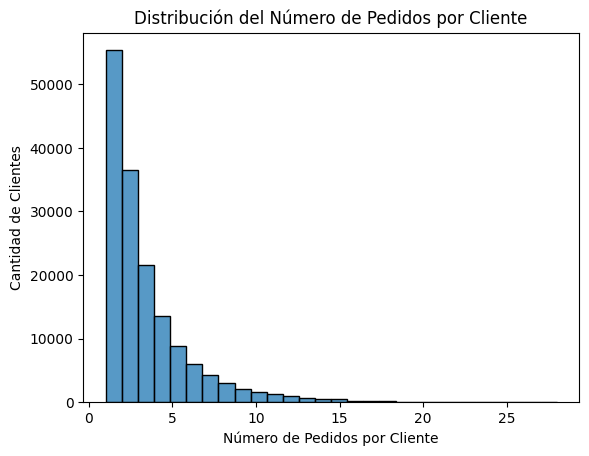

In [43]:
distribucion = df_ic.groupby('user_id')['order_id'].count()
print(distribucion.sort_values())
sns.histplot(distribucion, bins=28)
plt.title('Distribución del Número de Pedidos por Cliente')
plt.xlabel('Número de Pedidos por Cliente')
plt.ylabel('Cantidad de Clientes')
plt.show()

Poco menos de 60,000 clientes sólo realizan un sólo pedido, mientras que alrededor de 36,000 clientes realizan dos pedidos. 

### [c] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [44]:
pds_agds_cuenta = df_opds.groupby('product_id')['order_id'].count()
print(pds_agds_cuenta)
pds_ordenados = pds_agds_cuenta.sort_values(ascending=False)
print(pds_ordenados)
top_20_pds = pds_ordenados.head(20)
top_20_df = top_20_pds.reset_index()
print(top_20_df)
print(top_20_df)
merge_1 = top_20_df.merge(df_pds, on='product_id', how='left')
print(merge_1)


product_id
1        280
2         11
3         42
4         49
7          2
        ... 
49690      5
49691     72
49692     12
49693     25
49694      9
Name: order_id, Length: 45573, dtype: int64
product_id
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
         ...  
5836         1
43573        1
43570        1
36174        1
41403        1
Name: order_id, Length: 45573, dtype: int64
    product_id  order_id
0        24852     66050
1        13176     53297
2        21137     37039
3        21903     33971
4        47209     29773
5        47766     24689
6        47626     21495
7        16797     20018
8        26209     19690
9        27845     19600
10       27966     19197
11       22935     15898
12       24964     15292
13       45007     14584
14       39275     13879
15       49683     13675
16       28204     12544
17        5876     12232
18        8277     11993
19       40706     11781
    product_id  order_id
0        24852     66050
1      

Aquí se usó el parámetro 'how=left' puesto que quiero conservar todos los registros de la tabla principal (en este caso, la de la izquierda, que es 'top_20_df') y agregar información adicional de la otra tabla ('df_pds'). No es recomendable usar 'inner' en parámetro 'how=' puesto que sólo se queda con aquellos productos que existan en ambas tablas. Por lo que, si un producto del top 20 no tiene nombre en df_pds, se elimina completamente, con lo que podría perder productos importantes de mi ranking. 

## Parte III
Para esta parte, las instrucciones son las siguientes:

[a] ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?

[b] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

[c] Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?

[d] Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.

[e] ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [a] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [45]:
# Es necesario primero agrupar por pedido para juntar los valores únicos de sus IDs, para
# luego se haga el conteo de los artículos. De esta manera sabremos cuántos artículos hay 
# por pedido único
articulos_por_pedido = df_opds.groupby('order_id')['product_id'].count().reset_index()
print(articulos_por_pedido)

# En este punto se calculan las medidas de tendencia central (media, moda y mediana) para 
# tener un mejor insight de los datos.

media = articulos_por_pedido['product_id'].mean()
print(f"{media:.2f}")
mediana = articulos_por_pedido['product_id'].median()
print(mediana)
moda = articulos_por_pedido['product_id'].mode()[0]
print(moda)

        order_id  product_id
0              4          13
1              9          15
2             11           5
3             19           3
4             20           8
...          ...         ...
450041   3421034          17
450042   3421053           9
450043   3421071           5
450044   3421077           4
450045   3421079           1

[450046 rows x 2 columns]
10.10
8.0
5


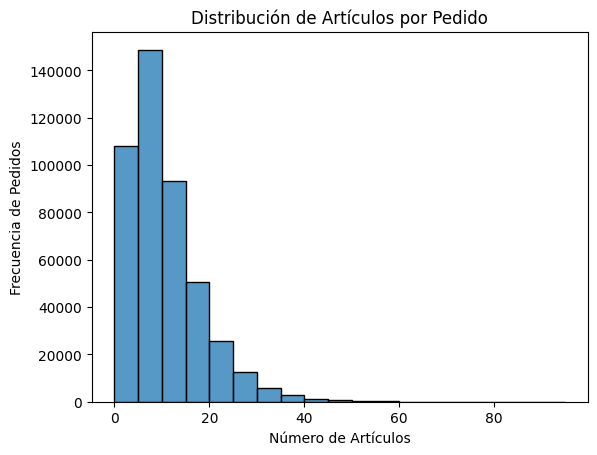

In [46]:
sns.histplot(articulos_por_pedido['product_id'], bins=range(0,100,5))
plt.xlabel('Número de Artículos')
plt.ylabel('Frecuencia de Pedidos')
plt.title('Distribución de Artículos por Pedido')
plt.show()

En primer lugar, hay que advertir que, en más de 140,000 pedidos, las personas compraron 10 artículos. Esto supera por bastant al segundo lugar, el cual, en poco menos de 110,000 pedidos, refleja compras de 5 artículos. Por otro lado, en lo que se refiere a las medidas de tendencia central, tenemos que el promedio de artículos por pedido es de 10.10, la moda o el número de artículos por pedido que más se repite es 5, mientras que la mediana es equivalente a 8. 

### [b] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [47]:
# Se comienza por un grouby tomando la variable 'product_id' como referencia, siendo 'reordered' a la que se le 
# aplica el método .sum(). Esto así para que se junten todas aquellas filas con los IDs idénticos de los productos y 
# puedan apreciarse los valores únicos de estos, cuyo nombre será asignado posteriormente con el 'merge'. 

fil_pds_reods = df_opds.groupby('product_id')['reordered'].sum()
fil_pds_reods = fil_pds_reods.sort_values(ascending=False)
print(fil_pds_reods)
fil_pds_reods = fil_pds_reods.head(20)

# Se resetea el index para que 'product_id' pasa a ser una columna y no un índice. 
fil_pds_reods = fil_pds_reods.reset_index()
print(fil_pds_reods)


product_id
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
         ...  
37593        0
14775        0
37596        0
14774        0
13714        0
Name: reordered, Length: 45573, dtype: int64
    product_id  reordered
0        24852      55763
1        13176      44450
2        21137      28639
3        21903      26233
4        47209      23629
5        47766      18743
6        27845      16251
7        47626      15044
8        27966      14748
9        16797      13945
10       26209      13327
11       22935      11145
12       24964      10411
13       45007      10076
14       49683       9538
15       28204       8989
16        8277       8836
17       39275       8799
18        5876       8412
19       49235       8389


In [48]:
merge_2 = fil_pds_reods.merge(df_pds, on='product_id', how='left')
merge_2

,product_id,reordered,product_name,aisle_id,department_id
0,24852,55763,BANANA,24,4
1,13176,44450,BAG OF ORGANIC BANANAS,24,4
2,21137,28639,ORGANIC STRAWBERRIES,24,4
3,21903,26233,ORGANIC BABY SPINACH,123,4
4,47209,23629,ORGANIC HASS AVOCADO,24,4
5,47766,18743,ORGANIC AVOCADO,24,4
6,27845,16251,ORGANIC WHOLE MILK,84,16
7,47626,15044,LARGE LEMON,24,4
8,27966,14748,ORGANIC RASPBERRIES,123,4
9,16797,13945,STRAWBERRIES,24,4


Se eligió el parámetro 'how=left' por las mismas razones que el ejercicio anterior. Esto es, porque quiero conservar todos los registros de la tabla principal (en este caso, la de la izquierda, que es 'fil_pds_reods') y agregar información adicional de la otra tabla ('df_pds'). No es recomendable usar 'inner' en parámetro 'how=' puesto que sólo se queda con aquellos productos que existan en ambas tablas. Por lo que, si un producto de la selección dentro de 'fil_pds_reods' no tiene nombre en df_pds, se elimina completamente, con lo que podría perder productos importantes de mi ranking. 

### [c] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [49]:
#
propor_reordered = df_opds.groupby('product_id')['reordered'].sum() / df_opds.groupby('product_id')['reordered'].count()
propor_reordered = propor_reordered.reset_index()
propor_reordered = propor_reordered.merge(df_pds, on='product_id', how='left')
propor_reordered

,product_id,reordered,product_name,aisle_id,department_id
0,1,0.564286,CHOCOLATE SANDWICH COOKIES,61,19
1,2,0.000000,ALL-SEASONS SALT,104,13
2,3,0.738095,ROBUST GOLDEN UNSWEETENED OOLONG TEA,94,7
3,4,0.510204,SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...,38,1
4,7,0.500000,PURE COCONUT WATER WITH ORANGE,98,7
...,...,...,...,...,...
45568,49690,0.800000,HIGH PERFORMANCE ENERGY DRINK,64,7
45569,49691,0.430556,ORIGINAL PANCAKE & WAFFLE MIX,130,14
45570,49692,0.416667,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
45571,49693,0.440000,SPRING WATER BODY WASH,127,11


En la primera solución, la respuesta depende de cada producto. Por ejemplo, la proporción en la que se ha vuelto a pedir el producto número 4 es de 51%, correspondiendo a PURE COCONUT WATER WITH ORANGE. 

### [d] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [50]:
df_opds['reordered'].sum()

2683838

In [ ]:
merge_3 = df_opds.merge(df_ic, on='order_id', how='inner')

prop_pds_reordenados = merge_3.groupby('user_id')['reordered'].sum() / merge_3.groupby('user_id')['reordered'].count()
prop_pds_reordenados = prop_pds_reordenados.reset_index()

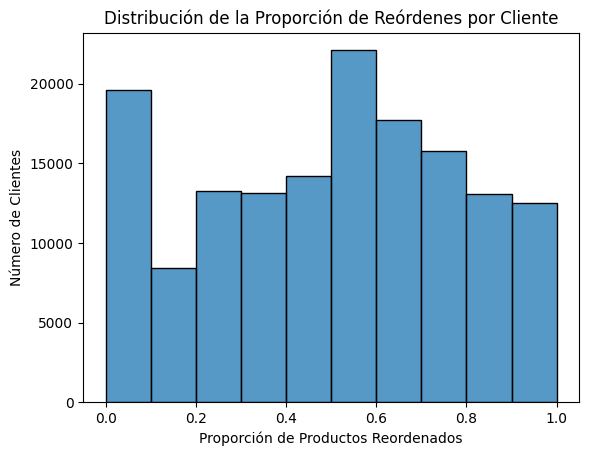

In [52]:
sns.histplot(prop_pds_reordenados['reordered'], bins=10)
plt.xlabel('Proporción de Productos Reordenados')
plt.ylabel('Número de Clientes')
plt.title('Distribución de la Proporción de Reórdenes por Cliente')
plt.show()

El 60% de los productos que ordenaron alrededor de 24,000 ya se habían pedido anteriormente. En segundo, lugar, se encuentra que el 10% de los productos de un aproximado de 19,000 clientes, ya se habían pedido.  

### [e] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [53]:
arti_1er_lugar = df_opds[df_opds['add_to_cart_order'] == 1]
prin_arti_1er = arti_1er_lugar.groupby('product_id')['add_to_cart_order'].sum()
prin_arti_1er = prin_arti_1er.reset_index()
prin_arti_1er
prin_arti_1er = prin_arti_1er.sort_values(by='add_to_cart_order', ascending=False)
prin_arti_1er = prin_arti_1er.head(20).reset_index(drop=True)
prin_arti_1er

,product_id,add_to_cart_order
0,24852,15562
1,13176,11026
2,27845,4363
3,21137,3946
4,47209,3390
5,21903,3336
6,47766,3044
7,19660,2336
8,16797,2308
9,27966,2024


In [54]:
merge_4 = prin_arti_1er.merge(df_pds, on='product_id', how='left')
merge_4

,product_id,add_to_cart_order,product_name,aisle_id,department_id
0,24852,15562,BANANA,24,4
1,13176,11026,BAG OF ORGANIC BANANAS,24,4
2,27845,4363,ORGANIC WHOLE MILK,84,16
3,21137,3946,ORGANIC STRAWBERRIES,24,4
4,47209,3390,ORGANIC HASS AVOCADO,24,4
5,21903,3336,ORGANIC BABY SPINACH,123,4
6,47766,3044,ORGANIC AVOCADO,24,4
7,19660,2336,SPRING WATER,115,7
8,16797,2308,STRAWBERRIES,24,4
9,27966,2024,ORGANIC RASPBERRIES,123,4


Se eligió el parámetro 'how=left' por las mismas razones que el ejercicio anterior. Esto es, porque quiero conservar todos los registros de la tabla principal (en este caso, la de la izquierda, que es 'prin_arti_1er') y agregar información adicional de la otra tabla ('df_pds'). No es recomendable usar 'inner' en parámetro 'how=' puesto que sólo se queda con aquellos productos que existan en ambas tablas. Por lo que, si un producto de la selección dentro de 'prin_arti_1er' no tiene nombre en df_pds, se elimina completamente, con lo que podría perder productos importantes de mi ranking. 

# Conclusiones
---

El análisis realizado permite identificar patrones de comportamiento relevantes en el uso de la plataforma, los cuales tienen implicaciones directas para la toma de decisiones estratégicas. En primer lugar, se observa una clara concentración de pedidos en determinadas franjas horarias, particularmente durante la mañana y el mediodía, lo que sugiere ventanas críticas de demanda que podrían optimizarse mediante estrategias logísticas y de asignación de recursos.

Asimismo, la distribución semanal de pedidos revela una mayor actividad al inicio de la semana (domingo y lunes), lo cual puede estar vinculado a dinámicas de consumo doméstico y planificación semanal. Este patrón podría ser aprovechado mediante promociones dirigidas o ajustes en la disponibilidad de inventario.

En cuanto al comportamiento de compra, destaca que los usuarios tienden a adquirir un número relativamente estable de productos por pedido (con una media cercana a 10), así como una alta proporción de productos recurrentes. Este último hallazgo es especialmente relevante, ya que sugiere una fuerte inercia en los hábitos de consumo, lo que abre oportunidades para sistemas de recomendación personalizados, suscripciones automatizadas o “listas inteligentes” que faciliten la recompra.

Adicionalmente, el hecho de que ciertos productos aparezcan con alta frecuencia tanto en pedidos generales como en primeras posiciones del carrito indica su centralidad en la experiencia de compra. Esto puede interpretarse como productos “ancla”, cuya disponibilidad y visibilidad deberían ser prioritarias dentro de la plataforma.

### **Recomendaciones estratégicas para Instacart**

1. **Optimización de la logística en horas pico**: reforzar la capacidad operativa en las horas de mayor demanda (mañana-mediodía) para reducir tiempos de entrega y mejorar la experiencia del usuario.

2. **Estrategias de fidelización basadas en recurrencia**: implementar sistemas de recompra automatizada o recordatorios inteligentes basados en patrones individuales de consumo.

3. **Promociones segmentadas por temporalidad**: aprovechar los picos de demanda semanales (domingo-lunes) para lanzar campañas específicas que incrementen el ticket promedio.

4. **Mejora de sistemas de recomendación**: utilizar la alta tasa de repetición de productos para afinar algoritmos que prioricen productos previamente comprados o similares.

5. **Gestión estratégica de productos clave**: asegurar la disponibilidad y visibilidad de los productos más frecuentes y aquellos que suelen añadirse primero al carrito, dado su papel central en la conversión de pedidos.

En conjunto, el análisis no solo permite comprender mejor el comportamiento del usuario, sino que también ofrece una base empírica para diseñar intervenciones que optimicen tanto la operación como la experiencia dentro de la plataforma.
